In [4]:
# install necessary dependencies
%pip install -q numpy pandas matplotlib statsmodels scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller            
from statsmodels.tsa.seasonal import seasonal_decompose   # identify seasonality in time series 
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    root_mean_squared_error
)

In [10]:
# load data
df = pd.read_csv("airline-passengers.csv")
print("Data set shape:", df.shape)
display(df.head())
display(df.tail())

Data set shape: (144, 2)


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


,Month,Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [11]:
# basic dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


In [12]:
# check misssing values
df.isnull().sum() 

Month         0
Passengers    0
dtype: int64

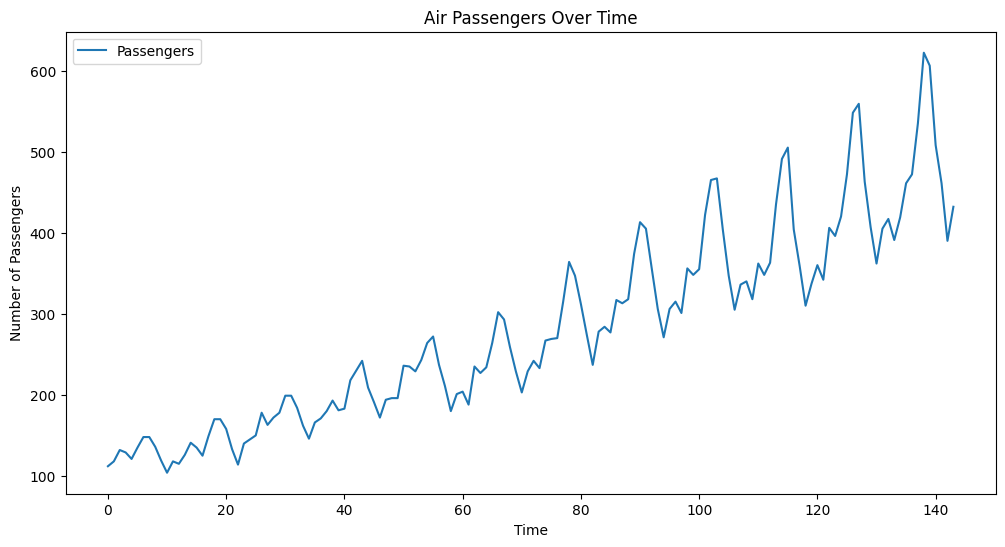

In [13]:
# plot time series data
plt.figure(figsize=(12, 6))
plt.plot(df["Passengers"], label= "Passengers")
plt.title("Air Passengers Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

>Seasonality is clearly visible

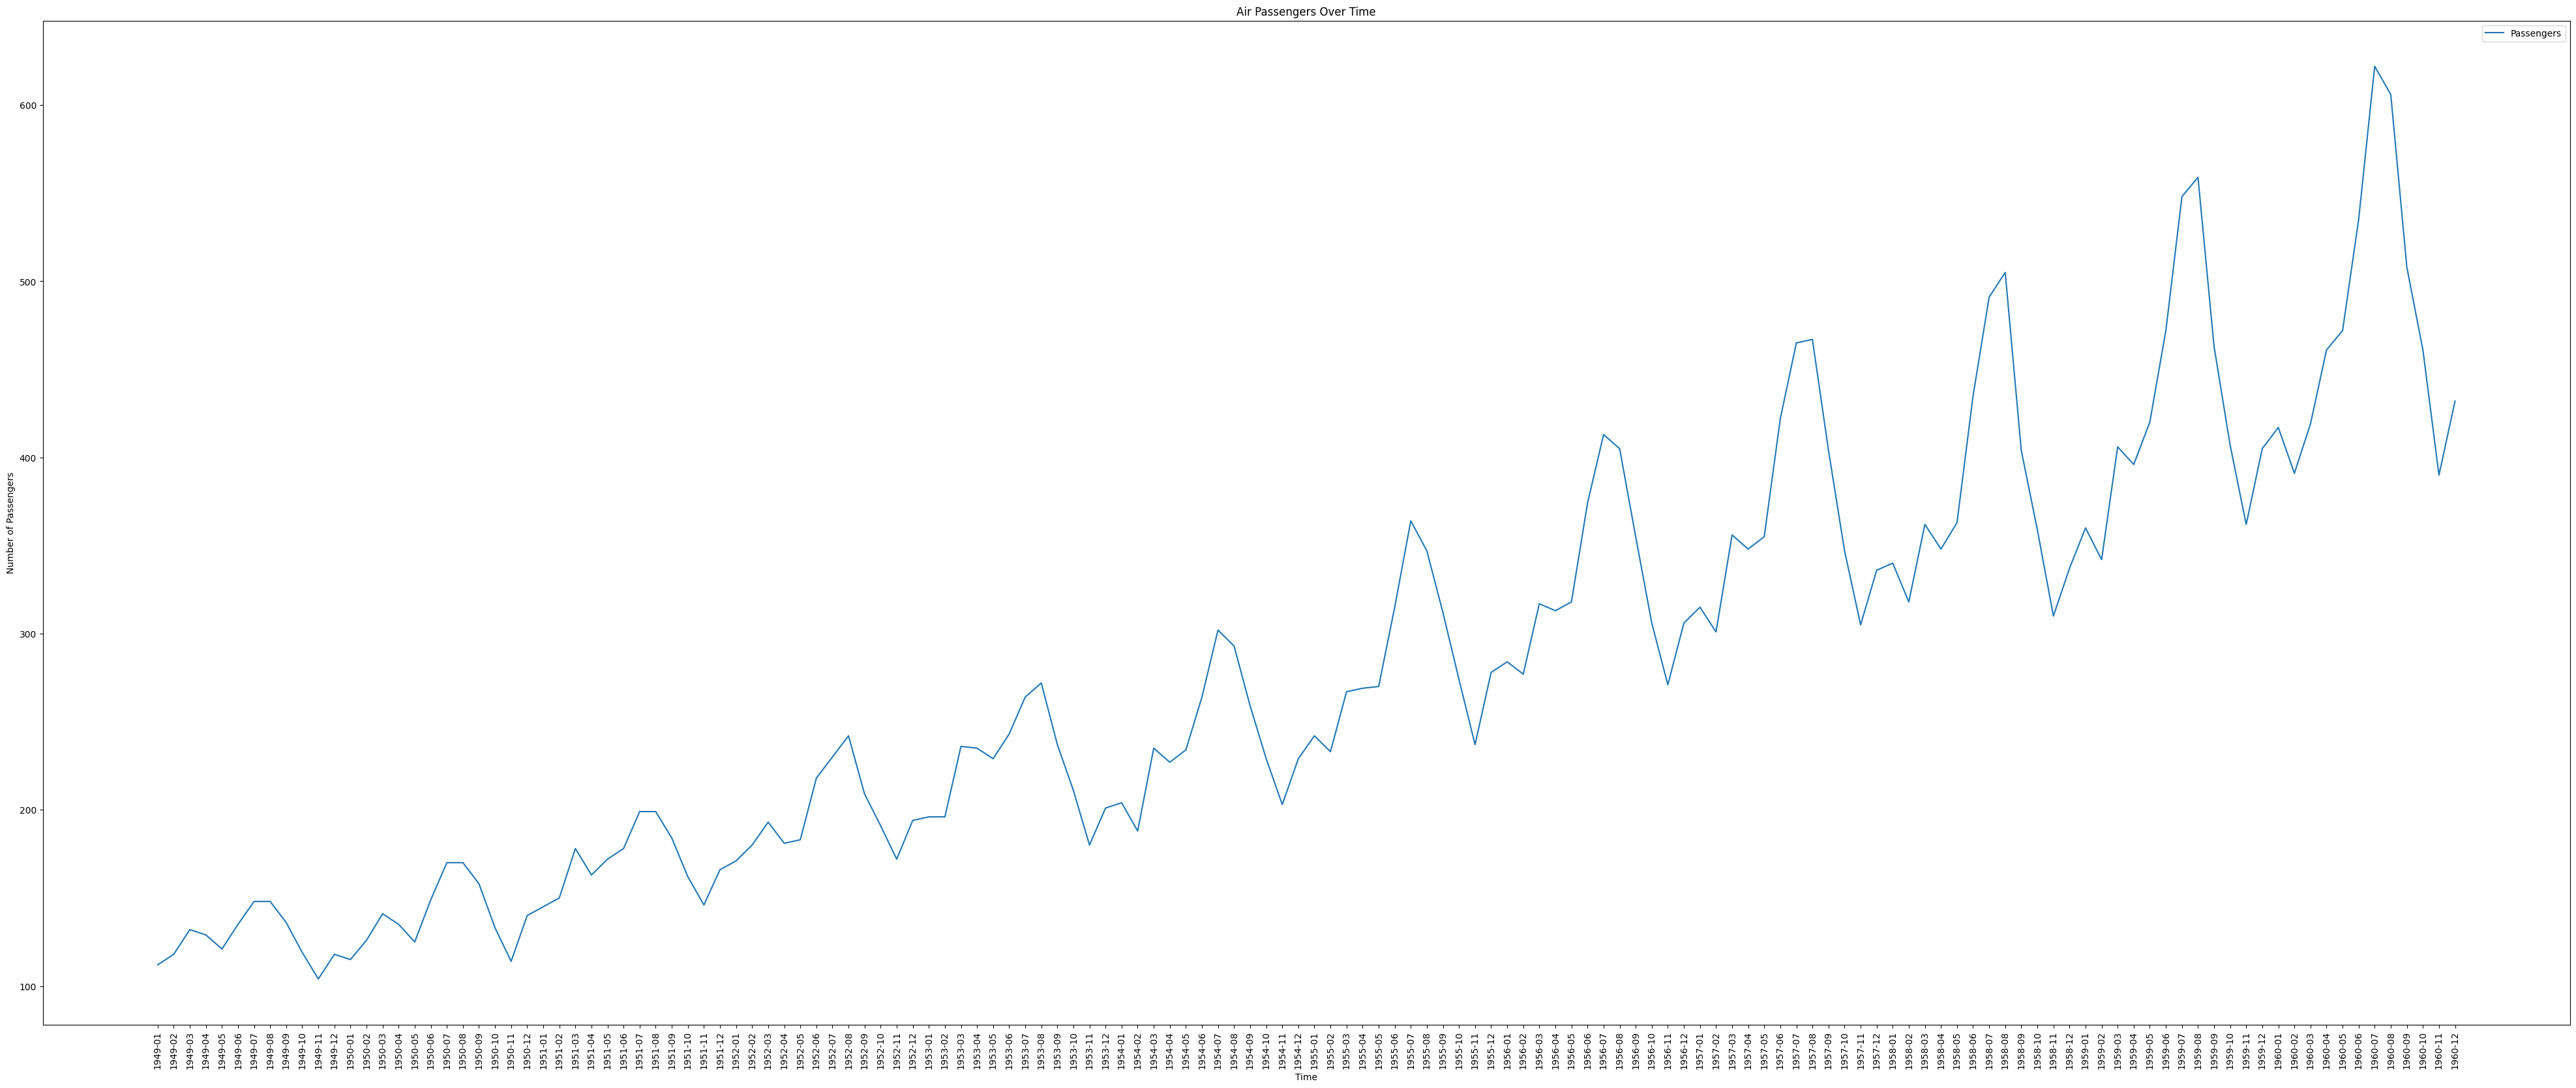

In [17]:
# plot time series data
plt.figure(figsize=(50, 20))
plt.plot(df["Month"],df["Passengers"], label= "Passengers")
plt.title("Air Passengers Over Time")
plt.xlabel("Time")
plt.xticks(rotation="vertical")  #rotate the x-axis labels for better visibility
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

In [ ]:
# Augmented Dickey-Fuller test for non-stationarity (seasonal data)
result = adfuller(df["Passengers"])
p_value = result[1]
ADF_value = result[0]
print(f"ADF Statistic: {ADF_value}")
print(f"p-value: {p_value}")

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


- Null hypothesis -> The data is non stationary (seasonal)
    - p_vavlues > 0.05
    - ADF_ value > 0.0
- Alternate hypothesis -> The data is stationary (non seasonal)
    - p_vavlues < 0.05
    - ADF_ value < 0.0

> Beacause of that also we can find that the dataset is a seasonal dataset

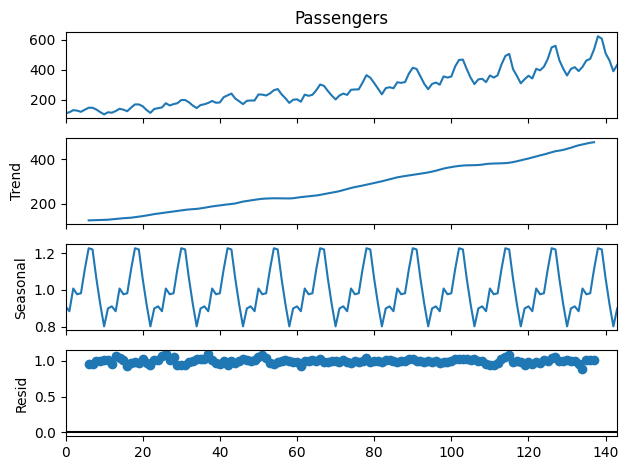

In [19]:
# seasonal decomposition
decomp = seasonal_decompose(
    df["Passengers"], 
    model="multiplicative", 
    period=12
)
decomp.plot()
plt.show()

In [20]:
# train test split
train = df.iloc[:-12]     #get all but the last 12 months for training
test = df.iloc[-12:]      #get the last 12 months for testing

In [23]:
test

,Month,Passengers
132,1960-01,417
133,1960-02,391
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461


In [22]:
train.head()


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
# train the model using ARIMA model
model = ARIMA(train['Passengers'],order=(5,1,0))
trained_model = model.fit()

In [25]:
forecast = trained_model.forecast(steps=12)
print("Forecasted values:", forecast)

Forecasted values: 132    458.449443
133    479.570529
134    480.136847
135    456.665327
136    435.835309
137    431.734529
138    437.928972
139    448.935482
140    455.562127
141    454.628434
142    450.095384
143    445.706018
Name: predicted_mean, dtype: float64


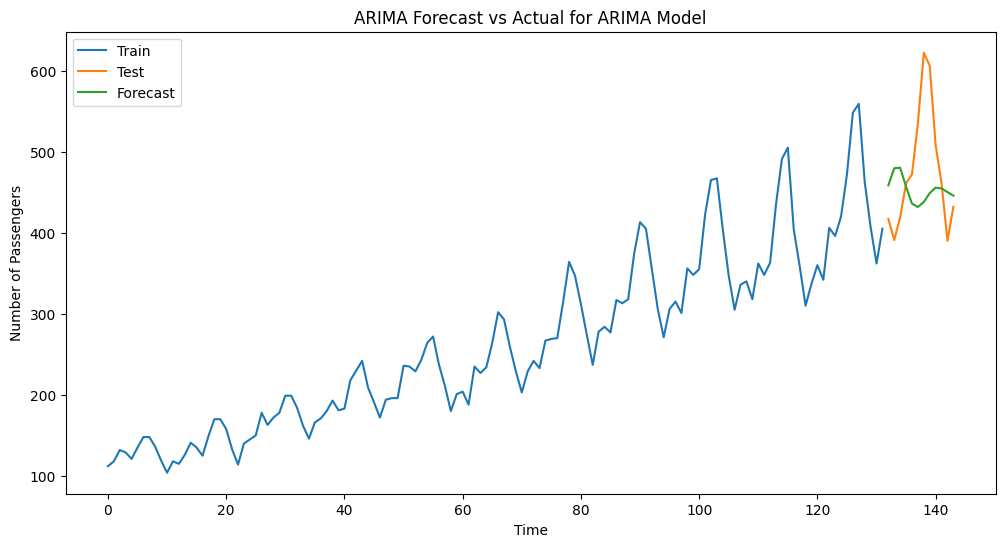

In [32]:
# plot actual vs forecasted values for ARIMA model  
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, forecast, label='Forecast')  
plt.title('ARIMA Forecast vs Actual for ARIMA Model')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

In [ ]:
# error metrics for ARIMA model
mae = mean_absolute_error(test['Passengers'], forecast)
mse = mean_squared_error(test['Passengers'], forecast)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 67.39
Mean Squared Error (MSE): 7536.00
Root Mean Squared Error (RMSE): 86.81


> The error is high so this is not good to use

In [29]:
# convert to log values
train_log = np.log(train['Passengers'])
test_log = np.log(test['Passengers'])

- by getting the log values the scale os change so the model can train more accurately

In [30]:
# SARIMAX model training
sarimax_model = SARIMAX(train_log, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarimax_trained_model = sarimax_model.fit()

In [31]:
# 12 month forecast using SARIMAX
sarimax_forecast_log = sarimax_trained_model.forecast(steps=12)
sarimax_forecast = np.exp(sarimax_forecast_log)  # convert back to original scale

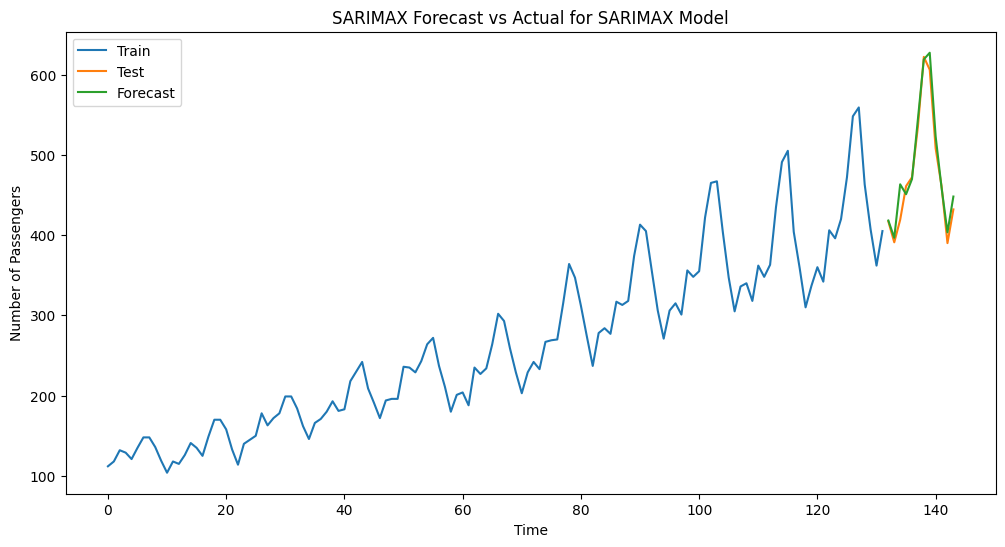

In [33]:
# plot actual vs forecasted values for SARIMAX model  
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Test')
plt.plot(test.index, sarimax_forecast, label='Forecast')  
plt.title('SARIMAX Forecast vs Actual for SARIMAX Model')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

In [35]:
# error metrics for SARIMAX model
mae = mean_absolute_error(test['Passengers'], sarimax_forecast)
mse = mean_squared_error(test['Passengers'], sarimax_forecast)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 11.97
Mean Squared Error (MSE): 276.14
Root Mean Squared Error (RMSE): 16.62
